# 重現性設定

In [1]:
import os
import numpy as np
import random
import tensorflow as tf

# 設定環境變數
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'

# 設定執行緒
try:
    tf.config.threading.set_inter_op_parallelism_threads(1)
    tf.config.threading.set_intra_op_parallelism_threads(1)
except RuntimeError as e:
    print(f"警告：設定失敗，原因可能是環境已初始化。{e}")

# 設定所有隨機種子
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("環境配置完成！")

環境配置完成！


# 載入資料集與預處理

In [2]:
from tensorflow.keras.datasets import cifar10
import tensorflow as tf
import numpy as np

# 載入資料集
(X_train_image, y_train_label), (X_test_image, y_test_label) = cifar10.load_data()

# reshape 轉成1維
y_train_label = y_train_label.reshape(-1)
y_test_label = y_test_label.reshape(-1)

# 進行標準化
X_train_normalize = X_train_image.astype('float32') / 255.0
X_test_normalize = X_test_image.astype('float32') / 255.0

# One-hot Encoding處理
from tensorflow.keras import utils

y_train_onehot = utils.to_categorical(y_train_label)
y_test_onehot = utils.to_categorical(y_test_label)

print('Train Data images:',X_train_normalize.shape)
print('Train Data labels:',y_train_onehot.shape)
print('Test Data images:',X_test_normalize.shape)
print('Test Data labels:',y_test_onehot.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Train Data images: (50000, 32, 32, 3)
Train Data labels: (50000, 10)
Test Data images: (10000, 32, 32, 3)
Test Data labels: (10000, 10)


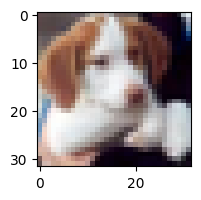

In [3]:
import matplotlib.pyplot as plt

def plot_image(image, img_size=1):
  fig = plt.gcf()
  fig.set_size_inches(2,2)
  plt.imshow(image, cmap='binary')
  plt.show()

augment_img = 16
plot_image(X_test_image[augment_img])

In [4]:
# 將影像增加為4維
print(X_test_normalize[augment_img].shape)

x_img = tf.expand_dims(X_test_normalize[augment_img], axis=0)
print(x_img.shape)

(32, 32, 3)
(1, 32, 32, 3)


# 建立單筆影像擴增資料

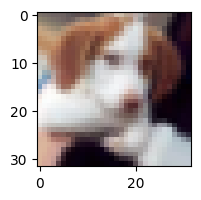

In [5]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(rotation_range=90) # 影像旋轉

fig = plt.gcf()
fig.set_size_inches(2, 2)

for batch in datagen.flow(x_img, batch_size=1):
  plt.imshow(batch[0])
  break

# 建立函數並顯示多筆影像擴增資料

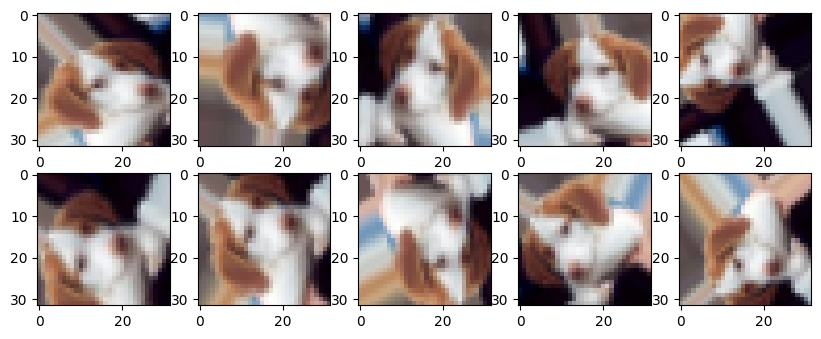

In [6]:
def display_ImageDataGenerator(datagen,x_img):
  fig = plt.gcf()
  fig.set_size_inches(10, 10)
  i = 1
  for batch in datagen.flow(x_img, batch_size=1):
    ax = plt.subplot(5, 5, i)
    ax.imshow(batch[0])
    i += 1
    if i > 10:
      break
  plt.show()

# datagen = ImageDataGenerator(rotation_range=180) # 影像旋轉
# datagen = ImageDataGenerator(width_shift_range=0.2) # 影像左右平移
# datagen = ImageDataGenerator(height_shift_range=0.2) # 影像上下平移
# datagen = ImageDataGenerator(zoom_range=0.2) # 影像長寬縮放
# datagen = ImageDataGenerator(horizontal_flip=True) # 影像水平翻轉
# datagen = ImageDataGenerator(vertical_flip=True) # 影像垂直翻轉

datagen = ImageDataGenerator(
    rotation_range=180,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2
)
display_ImageDataGenerator(datagen,x_img)

# Cifar-10資料進行影像資料擴增

In [7]:
import matplotlib.pyplot as plt

label_dict = {0: 'airplane', 1: 'automobile', 2: 'bird', 3: 'cat', 4: 'deer', 5: 'dog', 6: 'frog', 7: 'horse', 8: 'ship', 9: 'truck'}

def plot_images_labels_prediction(images, labels, prediction, idx, num=10):
    fig = plt.gcf()
    fig.set_size_inches(12, 14)
    if num > 25: num = 25
    for i in range(0, num):
        ax = plt.subplot(5, 5, i+1)
        ax.imshow(images[idx], cmap='binary')
        title = "label=" + str(label_dict[labels[idx]])
        if len(prediction) > 0:
            title += ", predict=" + str(label_dict[prediction[idx]])
        ax.set_title(title, fontsize=10)
        ax.set_xticks([]); ax.set_yticks([])
        idx += 1
    plt.show()

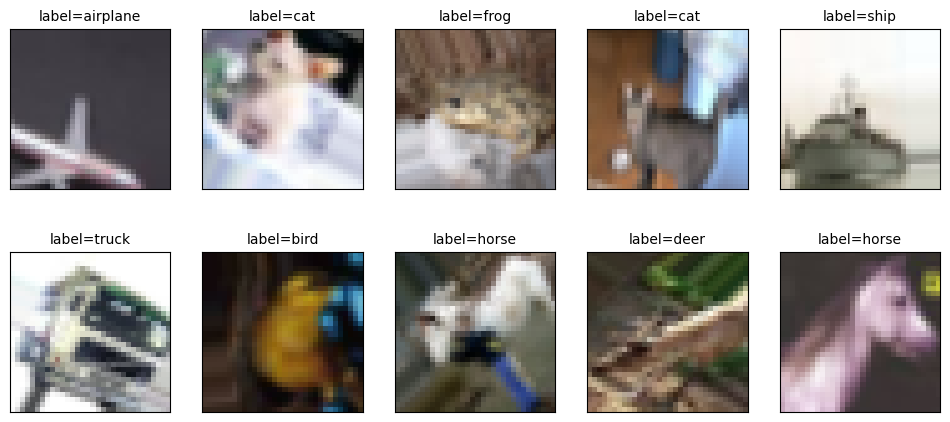

In [8]:
datagen = ImageDataGenerator(
    rotation_range=45,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2
)

for x_batch, y_batch in datagen.flow(X_train_normalize, y_train_label, batch_size=10):
    plot_images_labels_prediction(x_batch, y_batch, [], 0, 10)
    break

# 建立模型

In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Dropout, Flatten, Dense

model = Sequential()

# 卷積層
model.add(Conv2D(
    filters=32,
    kernel_size=(3,3),
    padding='same',
    input_shape=(32, 32, 3),
    activation='relu'))
# 池化層
model.add(MaxPooling2D(pool_size=(2,2)))

# 卷積層
model.add(Conv2D(
    filters=64,
    kernel_size=(3,3),
    padding='same',
    activation='relu'))
# 池化層
model.add(MaxPooling2D(pool_size=(2,2)))

# 卷積層
model.add(Conv2D(
    filters=128,
    kernel_size=(3,3),
    padding='same',
    activation='relu'))
# 池化層
model.add(MaxPooling2D(pool_size=(2,2)))

# 平坦層
model.add(Flatten())
# 隱藏層
model.add(Dense(128, activation='relu'))
# 輸出層
model.add(Dense(10, activation='softmax'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,810 (1.36 MB)

 Trainable params: 356,810 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=15,
    mode='min',)

In [11]:
!mkdir Model

In [12]:
filepath = 'Model/cifar10_model.h5'
checkpoint = ModelCheckpoint(
    filepath=filepath,
    monitor='val_acc',
    save_best_only=True,
    mode='max')

In [15]:
model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['acc'])

BATCH_SIZE = 200
train_history = model.fit(
    datagen.flow(X_train_normalize, y_train_onehot, batch_size=BATCH_SIZE),
    steps_per_epoch=len(X_train_normalize) // BATCH_SIZE,
    validation_data=(X_test_normalize, y_test_onehot),
    epochs=200,
    verbose=2,
    callbacks=[early_stopping,checkpoint])

Epoch 1/200


250/250 - 36s - 145ms/step - acc: 0.3264 - loss: 1.8281 - val_acc: 0.4561 - val_loss: 1.5189
Epoch 2/200


250/250 - 31s - 123ms/step - acc: 0.4301 - loss: 1.5846 - val_acc: 0.4911 - val_loss: 1.4016
Epoch 3/200


250/250 - 29s - 118ms/step - acc: 0.4704 - loss: 1.4745 - val_acc: 0.5224 - val_loss: 1.3376
Epoch 4/200


250/250 - 29s - 116ms/step - acc: 0.4970 - loss: 1.4075 - val_acc: 0.5266 - val_loss: 1.3817
Epoch 5/200


...

250/250 - 31s - 123ms/step - acc: 0.7476 - loss: 0.7205 - val_acc: 0.7674 - val_loss: 0.7087
Epoch 72/200
250/250 - 29s - 118ms/step - acc: 0.7508 - loss: 0.7110 - val_acc: 0.7655 - val_loss: 0.7127
Epoch 73/200
250/250 - 31s - 123ms/step - acc: 0.7477 - loss: 0.7173 - val_acc: 0.7659 - val_loss: 0.6992
Epoch 74/200


250/250 - 31s - 124ms/step - acc: 0.7521 - loss: 0.7088 - val_acc: 0.7713 - val_loss: 0.6974
Epoch 75/200


250/250 - 30s - 120ms/step - acc: 0.7507 - loss: 0.7109 - val_acc: 0.7777 - val_loss: 0.6619
Epoch 76/200
250/250 - 41s - 165ms/step - acc: 0.7538 - loss: 0.7068 - val_acc: 0.7743 - val_loss: 0.6865
Epoch 77/200


250/250 - 30s - 119ms/step - acc: 0.7544 - loss: 0.7030 - val_acc: 0.7786 - val_loss: 0.6584
Epoch 78/200
250/250 - 29s - 116ms/step - acc: 0.7557 - loss: 0.6998 - val_acc: 0.7726 - val_loss: 0.6981
Epoch 79/200
250/250 - 30s - 120ms/step - acc: 0.7561 - loss: 0.6992 - val_acc: 0.7661 - val_loss: 0.7218
Epoch 80/200
250/250 - 29s - 114ms/step - acc: 0.7578 - loss: 0.6950 - val_acc: 0.7768 - val_loss: 0.6817
Epoch 81/200
250/250 - 29s - 117ms/step - acc: 0.7561 - loss: 0.6947 - val_acc: 0.7711 - val_loss: 0.6887
Epoch 82/200


250/250 - 30s - 122ms/step - acc: 0.7591 - loss: 0.6912 - val_acc: 0.7841 - val_loss: 0.6584
Epoch 83/200
250/250 - 29s - 116ms/step - acc: 0.7573 - loss: 0.6946 - val_acc: 0.7775 - val_loss: 0.6784
Epoch 84/200
250/250 - 29s - 116ms/step - acc: 0.7586 - loss: 0.6932 - val_acc: 0.7666 - val_loss: 0.7004
Epoch 85/200
250/250 - 30s - 119ms/step - acc: 0.7597 - loss: 0.6857 - val_acc: 0.7777 - val_loss: 0.6764
Epoch 86/200
250/250 - 29s - 116ms/step - acc: 0.7615 - loss: 0.6851 - val_acc: 0.7496 - val_loss: 0.7979
Epoch 87/200
250/250 - 29s - 116ms/step - acc: 0.7596 - loss: 0.6854 - val_acc: 0.7779 - val_loss: 0.6688
Epoch 88/200
250/250 - 30s - 120ms/step - acc: 0.7607 - loss: 0.6861 - val_acc: 0.7739 - val_loss: 0.6859
Epoch 89/200
250/250 - 29s - 117ms/step - acc: 0.7627 - loss: 0.6804 - val_acc: 0.7741 - val_loss: 0.6823
Epoch 90/200
250/250 - 42s - 167ms/step - acc: 0.7620 - loss: 0.6782 - val_acc: 0.7811 - val_loss: 0.6693
Epoch 91/200
250/250 - 30s - 119ms/step - acc: 0.7645 - los

# 圖形顯示過程

In [16]:
import matplotlib.pyplot as plt

def show_train_history(train_history, train_key, validation_key):
    plt.plot(train_history.history[train_key], '--')
    plt.plot(train_history.history[validation_key])
    plt.title('Train History')
    plt.ylabel(train_key)
    plt.xlabel('Epoch')
    plt.legend(['train', 'validation'], loc='upper left')
    plt.show()

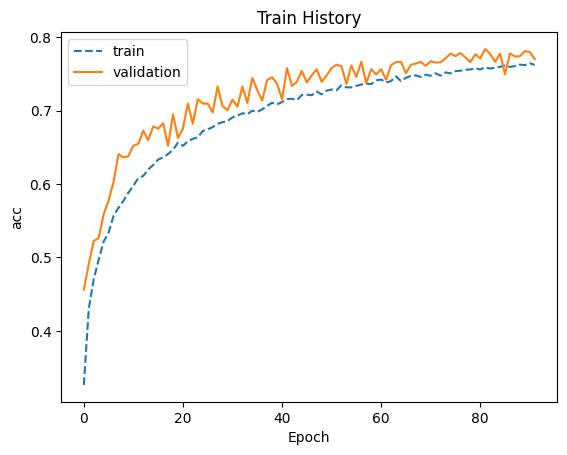

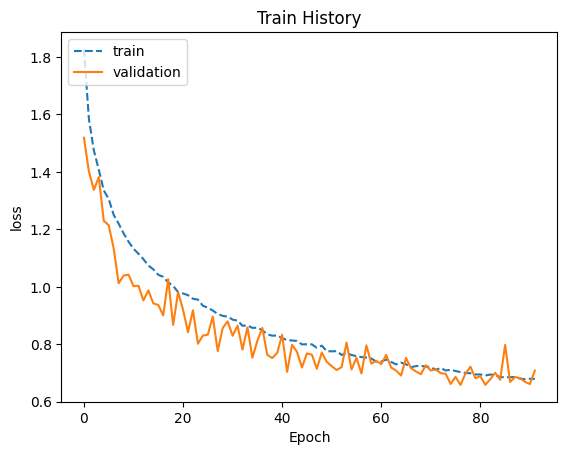

In [17]:
show_train_history(train_history, 'acc', 'val_acc')
show_train_history(train_history, 'loss', 'val_loss')

本範例可對比第20章和24章的結果，可看到Cifar-10資料進行影像資料擴增後train和validation的Accuracy以及Loss的曲線圖都非常接近且比先前的範例都好上許多